<a href="https://colab.research.google.com/github/yatin299/ML-LAB/blob/Logistical-Regression/Logistical_Regression_P_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (768, 9)
   pregnant  glucose  bp  skin  insulin   bmi  pedigree  age  outcome
0         6      148  72    35        0  33.6     0.627   50        1
1         1       85  66    29        0  26.6     0.351   31        0
2         8      183  64     0        0  23.3     0.672   32        1
3         1       89  66    23       94  28.1     0.167   21        0
4         0      137  40    35      168  43.1     2.288   33        1

Accuracy: 0.7468 (74%)


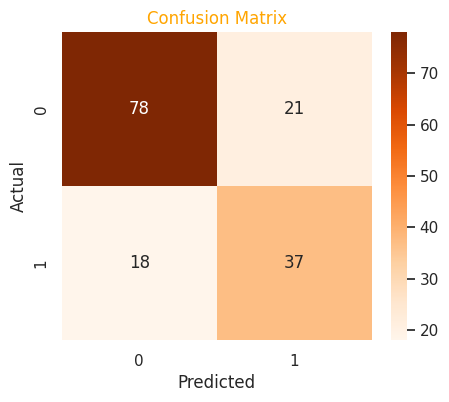

In [17]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (direct CSV URL)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['pregnant','glucose','bp','skin','insulin','bmi','pedigree','age','outcome']
df = pd.read_csv(url, header=None, names=columns)

# Quick look
print("Dataset shape:", df.shape)
print(df.head())

# Features & target
X = df.drop('outcome', axis=1)
y = df['outcome']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
model = LogisticRegression(max_iter=1000, solver='lbfgs')
model.fit(X_train, y_train)

# Predictions & accuracy
y_pred = model.predict(X_test)
acc = metrics.accuracy_score(y_test, y_pred)
print("\nAccuracy:", round(acc,4), f"({int(acc*100)}%)")

# Confusion Matrix + Heatmap
conf_mat = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Oranges')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix", color="orange")
plt.show()
